# Tugas — skforecast
Sumber: skforecast.org/0.15.1/user_guides/explainability.html

## Install library-nya

In [1]:
!pip install -q skforecast==0.15.1 lightgbm shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 812.8/812.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 10.8 MB/s eta 0:00:00


## Import

In [4]:
# Libraries
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay
from lightgbm import LGBMRegressor

from skforecast.datasets import fetch_dataset
from skforecast.recursive import ForecasterRecursive

## Ambil Dataset Skforecast

In [5]:
# Download data
# ==============================================================================
data = fetch_dataset(name="vic_electricity")
data.head(3)

vic_electricity
---------------
Half-hourly electricity demand for Victoria, Australia
O'Hara-Wild M, Hyndman R, Wang E, Godahewa R (2022).tsibbledata: Diverse
Datasets for 'tsibble'. https://tsibbledata.tidyverts.org/,
https://github.com/tidyverts/tsibbledata/.
https://tsibbledata.tidyverts.org/reference/vic_elec.html
Shape of the dataset: (52608, 4)


,Demand,Temperature,Date,Holiday
Time,,,,
2011-12-31 13:00:00,4382.825174,21.40,2012-01-01,True
2011-12-31 13:30:00,4263.365526,21.05,2012-01-01,True
2011-12-31 14:00:00,4048.966046,20.70,2012-01-01,True


Dataset ini adalah data electricity demand Victoria, Australia. Pada dokumentasi skforecast, dataset awalnya memiliki 52.608 record dengan informasi permintaan listrik, suhu, tanggal, dan hari libur.

## Agregasi data menjadi harian

In [6]:
# Aggregation to daily frequency
# ==============================================================================
data = data.resample('D').agg({'Demand': 'sum','Temperature': 'mean'})

data.head(3)

,Demand,Temperature
Time,,
2011-12-31,82531.745918,21.047727
2012-01-01,227778.257304,26.578125
2012-01-02,275490.988882,31.751042




Data awal pada dataset `vic_electricity` memiliki frekuensi waktu yang lebih detail. Oleh karena itu, data diagregasi menjadi frekuensi harian.

Kolom `Demand` dijumlahkan per hari karena menunjukkan total permintaan listrik harian. Sementara itu, kolom `Temperature` dirata-ratakan per hari karena suhu harian lebih tepat direpresentasikan dengan nilai rata-rata.

Hasil dari proses ini adalah dataset harian yang berisi total permintaan listrik dan rata-rata suhu per hari.

### Visualisasi


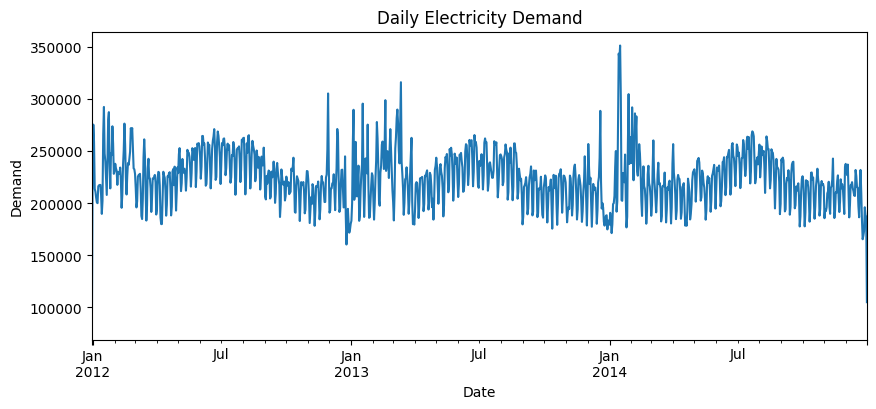

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
data['Demand'].plot(ax=ax)
ax.set_title('Daily Electricity Demand')
ax.set_xlabel('Date')
ax.set_ylabel('Demand')
plt.show()

## Split data training dan testing

Pada dokumentasi skforecast, data training digunakan sampai 2014-12-21, sedangkan data testing dimulai dari 2014-12-22

In [8]:
# Split train-test
# ==============================================================================
data_train = data.loc[: '2014-12-21']
data_test = data.loc['2014-12-22':]

print(f"Train dates : {data_train.index.min()} --- {data_train.index.max()}  (n={len(data_train)})")
print(f"Test dates  : {data_test.index.min()} --- {data_test.index.max()}  (n={len(data_test)})")

Train dates : 2011-12-31 00:00:00 --- 2014-12-21 00:00:00  (n=1087)
Test dates  : 2014-12-22 00:00:00 --- 2014-12-31 00:00:00  (n=10)


Data dibagi menjadi data training dan data testing berdasarkan urutan waktu. Pada time series, pembagian data tidak dilakukan secara acak karena urutan waktu harus tetap dijaga.

Data training digunakan untuk melatih model, sedangkan data testing digunakan untuk mengevaluasi kemampuan model dalam memprediksi data yang belum pernah dilihat sebelumnya.

## Melatih model forecasting

In [9]:
# Create a recursive multi-step forecaster
# ==============================================================================
forecaster = ForecasterRecursive(
    regressor = LGBMRegressor(random_state=123, verbose=-1),
    lags      = 7
)

forecaster.fit(
    y    = data_train['Demand'],
    exog = data_train['Temperature']
)

forecaster

=================== 
ForecasterRecursive 
=================== 
Regressor: LGBMRegressor 
Lags: [1 2 3 4 5 6 7] 
Window features: None 
Window size: 7 
Exogenous included: True 
Exogenous names: Temperature 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [Timestamp('2011-12-31 00:00:00'), Timestamp('2014-12-21 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: D 
Regressor parameters: 
    {'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0,
    'importance_type': 'split', 'learning_rate': 0.1, 'max_depth': -1,
    'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0,
    'n_estimators': 100, 'n_jobs': None, 'num_leaves': 31, 'objective': None,
    'random_state': 123, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample': 1.0,
    'subsample_for_bin': 200000, 'subsample_freq': 0, 'verbose': -1} 
fit_kwargs: {} 
Creation date: 2026-06-10 11:08:15 
Last fit date: 2026-06-10 11:08:15 
Skforecast version: 0.15.1 
Python version: 3.12.13 
Forecaster id: None

Model yang digunakan adalah `ForecasterRecursive` dengan algoritma `LGBMRegressor`. Model ini bekerja dengan pendekatan recursive forecasting, yaitu prediksi dilakukan secara bertahap ke depan.

Parameter `lags=7` berarti model menggunakan 7 nilai `Demand` sebelumnya sebagai input untuk memprediksi nilai `Demand` berikutnya. Selain lag, model juga menggunakan `Temperature` sebagai variabel eksogen.

## Feature importance

In [10]:
# Predictors importances
# ==============================================================================
feature_importance = forecaster.get_feature_importances()
feature_importance

,feature,importance
7,Temperature,570
0,lag_1,470
2,lag_3,387
1,lag_2,362
6,lag_7,325
5,lag_6,313
4,lag_5,298
3,lag_4,275




Feature importance digunakan untuk melihat fitur mana yang paling berkontribusi terhadap prediksi model. Fitur yang dianalisis dalam model ini adalah `lag_1` sampai `lag_7` dan `Temperature`.

Nilai feature importance yang lebih tinggi menunjukkan bahwa fitur tersebut lebih sering atau lebih kuat digunakan oleh model dalam proses prediksi. Namun, feature importance tidak menunjukkan hubungan sebab-akibat, melainkan hanya menunjukkan kontribusi fitur dalam model.

## Bentuk data training: input dan output

In [11]:
# Training matrices used by the forecaster
# ==============================================================================
X_train, y_train = forecaster.create_train_X_y(
    y    = data_train['Demand'],
    exog = data_train['Temperature']
)

display(X_train.head(3))
display(y_train.head(3))

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,Temperature
Time,,,,,,,,
2012-01-07,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,227778.257304,82531.745918,24.098958
2012-01-08,200693.270298,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,227778.257304,20.223958
2012-01-09,200061.614738,200693.270298,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,19.161458


,y
Time,
2012-01-07,200693.270298
2012-01-08,200061.614738
2012-01-09,216201.836844


Pada bagian ini, data time series diubah menjadi bentuk supervised learning. Proses ini menghasilkan dua objek utama, yaitu `X_train` dan `y_train`.

`X_train` adalah input model yang terdiri dari:
- `lag_1`
- `lag_2`
- `lag_3`
- `lag_4`
- `lag_5`
- `lag_6`
- `lag_7`
- `Temperature`

Sedangkan `y_train` adalah output atau target model, yaitu `Demand`.

Dengan demikian, model memprediksi `Demand` hari ini berdasarkan nilai `Demand` pada 1 sampai 7 hari sebelumnya dan suhu pada hari tersebut.

## SHAP explainer

In [12]:
# Create SHAP explainer
# ==============================================================================
shap.initjs()

explainer = shap.TreeExplainer(forecaster.regressor)
shap_values = explainer.shap_values(X_train)

SHAP digunakan untuk menjelaskan kontribusi setiap fitur terhadap hasil prediksi model. Pada tahap ini dibuat objek explainer menggunakan `TreeExplainer` karena model yang digunakan adalah LightGBM, yaitu model berbasis tree.

SHAP memberikan nilai kontribusi untuk setiap fitur, sehingga dapat diketahui apakah suatu fitur menaikkan atau menurunkan hasil prediksi.

## SHAP summary plot bentuk bar

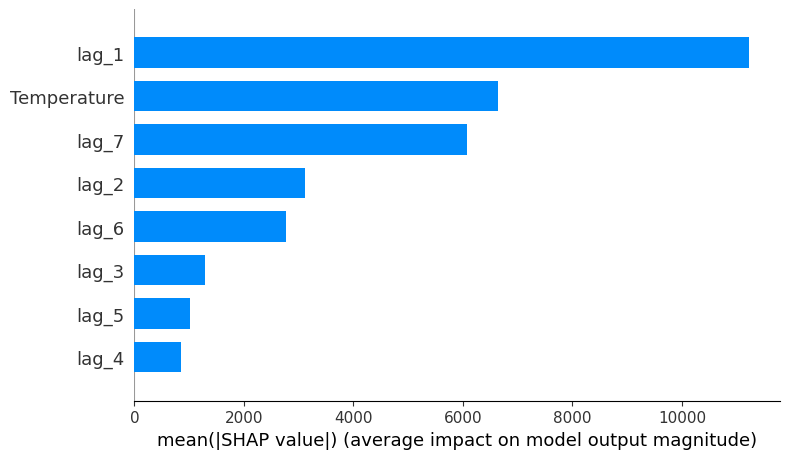

In [13]:
shap.summary_plot(shap_values, X_train, plot_type="bar")

SHAP summary plot dalam bentuk bar digunakan untuk melihat rata-rata pengaruh setiap fitur terhadap prediksi model. Semakin besar nilai SHAP suatu fitur, semakin besar kontribusi fitur tersebut terhadap hasil prediksi secara keseluruhan.

Grafik ini membantu mengetahui fitur mana yang paling dominan dalam memengaruhi prediksi model.

## SHAP summary plot lengkap

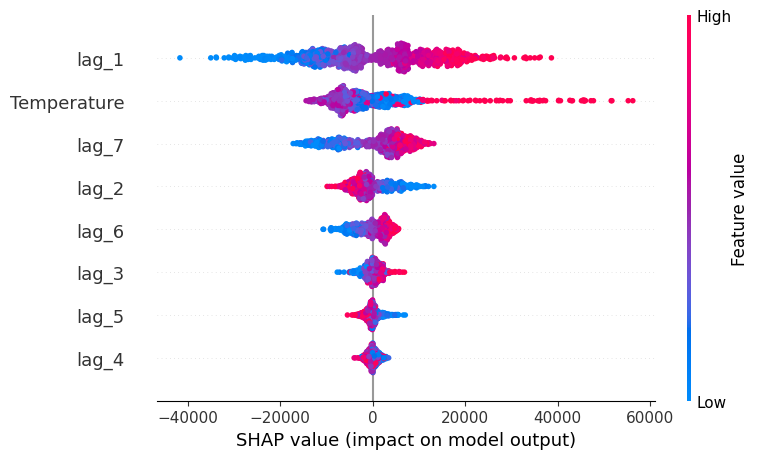

In [14]:
shap.summary_plot(shap_values, X_train)

SHAP summary plot digunakan untuk melihat besar dan arah pengaruh fitur terhadap prediksi. Setiap titik merepresentasikan satu observasi pada data training.

Warna merah menunjukkan nilai fitur yang tinggi, sedangkan warna biru menunjukkan nilai fitur yang rendah. Titik yang berada di sisi kanan menunjukkan bahwa fitur tersebut mendorong prediksi menjadi lebih tinggi, sedangkan titik di sisi kiri menunjukkan bahwa fitur tersebut mendorong prediksi menjadi lebih rendah.

## Explain individual observation

In [15]:
# Explain individual observation
# ==============================================================================

import shap
from IPython.display import display

shap.initjs()

force_plot = shap.force_plot(
    explainer.expected_value,
    shap_values[0, :],
    X_train.iloc[0, :]
)

display(force_plot)

Pada bagian ini dilakukan penjelasan terhadap satu observasi tertentu menggunakan SHAP force plot. Tujuannya adalah untuk melihat fitur mana yang mendorong hasil prediksi menjadi lebih tinggi atau lebih rendah dari nilai dasar model.

Force plot menjelaskan prediksi secara lokal, artinya penjelasan hanya berlaku untuk satu baris data atau satu observasi tertentu.

## Visualize many predictions

In [16]:
# Force plot for the first 200 observations in the training set
# ==============================================================================
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[:200, :], X_train.iloc[:200, :])

## SHAP dependence plot untuk Temperature

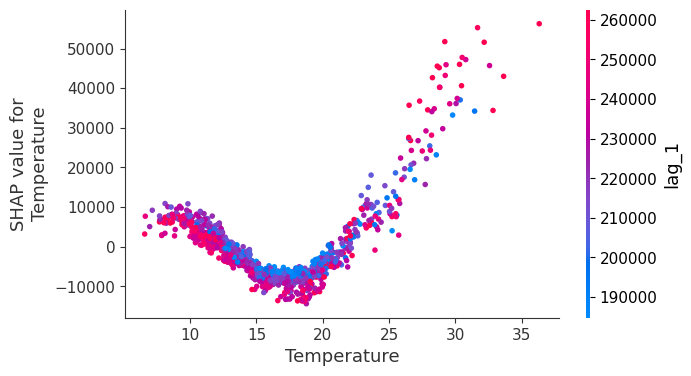

In [17]:
# Dependence plot for Temperature
# ==============================================================================
fig, ax = plt.subplots(figsize=(7, 4))
shap.dependence_plot("Temperature", shap_values, X_train, ax=ax)

SHAP dependence plot digunakan untuk melihat hubungan antara nilai suatu fitur dengan kontribusinya terhadap prediksi. Pada bagian ini fitur yang dianalisis adalah `Temperature`.

Plot ini membantu memahami apakah perubahan suhu cenderung meningkatkan atau menurunkan prediksi permintaan listrik.

## Prediksi 7 hari ke depan

In [21]:
# Predict
# ==============================================================================
predictions = forecaster.predict(
    steps = 7,
    exog  = data_test['Temperature']
)

predictions

,pred
2014-12-22,241514.532543
2014-12-23,226165.936559
2014-12-24,220506.468700
2014-12-25,209260.948991
2014-12-26,184885.145832
2014-12-27,195623.591810
2014-12-28,222766.340659
2014-12-29,223112.716406
2014-12-30,219103.891733


Setelah model dilatih, model digunakan untuk memprediksi `Demand` selama 7 hari ke depan. Prediksi dilakukan menggunakan data `Temperature` dari periode testing sebagai variabel eksogen.

Hasil prediksi ini menunjukkan estimasi permintaan listrik harian yang dihasilkan oleh model berdasarkan pola permintaan listrik sebelumnya dan suhu.

## Membuat input matrix untuk prediksi

In [22]:
# Create input matrix for predict method
# ==============================================================================
X_predict = forecaster.create_predict_X(
    steps = 7,
    exog  = data_test['Temperature']
)

X_predict

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,Temperature
2014-12-22,216483.631690,186486.896670,197129.766534,214934.022460,215507.677076,226093.767670,231923.044018,22.950000
2014-12-23,241514.532543,216483.631690,186486.896670,197129.766534,214934.022460,215507.677076,226093.767670,18.829167
2014-12-24,226165.936559,241514.532543,216483.631690,186486.896670,197129.766534,214934.022460,215507.677076,18.312500
2014-12-25,220506.468700,226165.936559,241514.532543,216483.631690,186486.896670,197129.766534,214934.022460,16.933333
2014-12-26,209260.948991,220506.468700,226165.936559,241514.532543,216483.631690,186486.896670,197129.766534,16.429167
2014-12-27,184885.145832,209260.948991,220506.468700,226165.936559,241514.532543,216483.631690,186486.896670,18.189583
2014-12-28,195623.591810,184885.145832,209260.948991,220506.468700,226165.936559,241514.532543,216483.631690,24.539583



`X_predict` adalah matriks input yang digunakan model ketika melakukan prediksi ke depan. Isinya terdiri dari nilai lag dan variabel eksogen yang dibutuhkan untuk menghasilkan prediksi.

Pada metode recursive forecasting, hasil prediksi pada langkah sebelumnya dapat digunakan sebagai lag untuk memprediksi langkah berikutnya.

## SHAP untuk hasil prediksi tertentu

In [24]:
# Force plot for a specific prediction
# ==============================================================================
shap.initjs()
predicted_date = '2014-12-24'
iloc_predicted_date = X_predict.index.get_loc(predicted_date)

shap_values_predict = explainer.shap_values(X_predict)

shap.force_plot(
    explainer.expected_value,
    shap_values_predict[iloc_predicted_date, :],
    X_predict.iloc[iloc_predicted_date, :]
)

Pada bagian ini SHAP digunakan untuk menjelaskan hasil prediksi pada tanggal tertentu. Tujuannya adalah untuk mengetahui fitur apa saja yang berkontribusi terhadap nilai prediksi pada tanggal tersebut.

Dengan pendekatan ini, kita dapat memahami alasan model menghasilkan nilai prediksi tertentu, bukan hanya melihat angka prediksinya saja.

## Permutation feature importance

In [25]:
# Permutation importances
# ==============================================================================
r = permutation_importance(
    estimator    = forecaster.regressor,
    X            = X_train,
    y            = y_train,
    n_repeats    = 3,
    max_samples  = 0.5,
    random_state = 123
)

importances = pd.DataFrame({
    'feature': X_train.columns,
    'mean_importance': r.importances_mean,
    'std_importance': r.importances_std
}).sort_values('mean_importance', ascending=False)

importances

,feature,mean_importance,std_importance
0,lag_1,0.617276,0.014583
7,Temperature,0.411240,0.014405
6,lag_7,0.196190,0.001865
1,lag_2,0.122398,0.007803
5,lag_6,0.083912,0.003637
2,lag_3,0.041294,0.002019
4,lag_5,0.030787,0.001079
3,lag_4,0.024816,0.001021


Permutation importance digunakan untuk mengukur pentingnya suatu fitur dengan cara mengacak nilai fitur tersebut, kemudian melihat penurunan performa model.

Jika setelah suatu fitur diacak performa model menurun besar, maka fitur tersebut dianggap penting. Sebaliknya, jika performa model tidak banyak berubah, berarti fitur tersebut tidak terlalu berpengaruh terhadap prediksi.

## Partial Dependence Plot

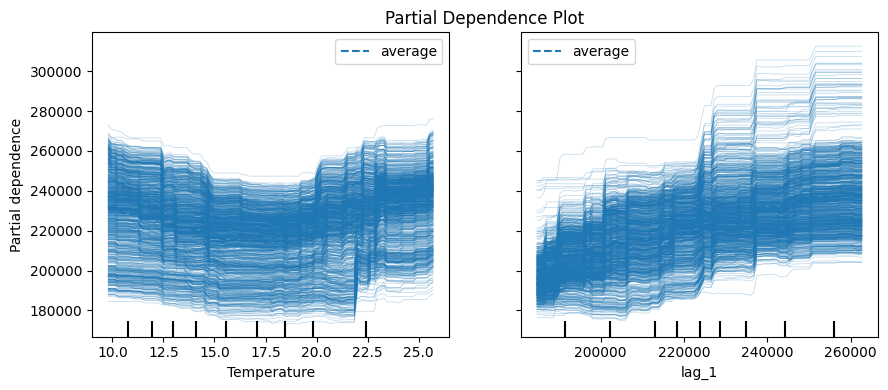

In [26]:
# Partial dependence plots
# ==============================================================================
fig, ax = plt.subplots(figsize=(9, 4))

PartialDependenceDisplay.from_estimator(
    estimator = forecaster.regressor,
    X         = X_train,
    features  = ["Temperature", "lag_1"],
    kind      = 'both',
    ax        = ax
)

ax.set_title("Partial Dependence Plot")
fig.tight_layout()
plt.show()

Partial Dependence Plot digunakan untuk melihat hubungan rata-rata antara suatu fitur dan hasil prediksi model. Pada bagian ini fitur yang dianalisis adalah `Temperature` dan `lag_1`.

Plot ini membantu memahami bagaimana perubahan nilai fitur tertentu dapat memengaruhi prediksi, dengan mempertimbangkan fitur lainnya secara rata-rata.

## PERTANYAAN

### 1. Analisa prediksi tentang apa?

Analisa prediksi pada kasus ini membahas tentang prediksi permintaan listrik harian atau daily electricity demand di Victoria, Australia.

Jadi, model dibuat untuk memperkirakan berapa besar kebutuhan listrik pada hari-hari berikutnya berdasarkan data sebelumnya. Data yang digunakan berasal dari dataset vic_electricity pada dokumentasi skforecast explainability.

### 2. Bagaimana bentuk data trainingnya?

Data awal berbentuk time series, yaitu data yang tersusun berdasarkan waktu. Kemudian data tersebut diubah menjadi bentuk supervised learning, supaya bisa digunakan untuk melatih model machine learning.

Input model / X_train terdiri dari:

- lag_1
, yaitu nilai demand listrik 1 hari sebelumnya.
- lag_2
, yaitu nilai demand listrik 2 hari sebelumnya.
- lag_3
, yaitu nilai demand listrik 3 hari sebelumnya.
- lag_4
, yaitu nilai demand listrik 4 hari sebelumnya.
- lag_5
, yaitu nilai demand listrik 5 hari sebelumnya.
- lag_6
, yaitu nilai demand listrik 6 hari sebelumnya.
- lag_7
, yaitu nilai demand listrik 7 hari sebelumnya.
- Temperature
, yaitu suhu harian sebagai variabel tambahan atau variabel eksogen.

Output model / y_train adalah:

- Demand, yaitu jumlah permintaan listrik harian yang ingin diprediksi.

Jadi, secara sederhana model belajar seperti ini:

Demand hari ini diprediksi menggunakan demand 1 sampai 7 hari sebelumnya dan suhu pada hari tersebut.

### 3. Apa itu lag?

Lag adalah data dari periode sebelumnya yang digunakan untuk memprediksi data pada periode berikutnya.

Dalam kasus ini, karena datanya harian, maka:

- lag_1 berarti demand listrik 1 hari sebelumnya.
- lag_2 berarti demand listrik 2 hari sebelumnya.
- lag_7 berarti demand listrik 7 hari sebelumnya.

Contohnya, jika model ingin memprediksi demand listrik tanggal 8 Januari, maka model bisa menggunakan data demand tanggal 1 sampai 7 Januari sebagai input.

Lag penting dalam analisis time series karena pola masa lalu biasanya memengaruhi nilai masa depan. Misalnya, penggunaan listrik hari ini bisa dipengaruhi oleh penggunaan listrik beberapa hari sebelumnya.

### 4. Jelaskan proses analisis yang dilakukan

Proses analisis pada kasus ini dilakukan melalui beberapa tahap.

- Pertama, dilakukan pengambilan dataset menggunakan dataset vic_electricity dari skforecast. Dataset ini berisi data permintaan listrik, suhu, tanggal, dan informasi waktu lainnya.

- Kedua, data kemudian diagregasi menjadi data harian. Kolom Demand dijumlahkan per hari karena menunjukkan total permintaan listrik harian. Sedangkan kolom Temperature dirata-ratakan per hari karena suhu harian lebih cocok dilihat dari rata-ratanya.

- Ketiga, data dibagi menjadi data training dan data testing. Data training digunakan untuk melatih model, sedangkan data testing digunakan untuk melihat apakah model mampu memprediksi data baru yang belum pernah dipelajari.

- Keempat, model forecasting dibuat menggunakan ForecasterRecursive dengan algoritma LGBMRegressor. Model ini menggunakan lags = 7, artinya model menggunakan 7 nilai demand sebelumnya untuk memprediksi demand berikutnya. Selain itu, model juga menggunakan Temperature sebagai input tambahan.

- Kelima, setelah model dilatih, dilakukan analisis feature importance untuk melihat fitur mana yang paling berpengaruh terhadap prediksi. Fitur yang dianalisis adalah lag_1 sampai lag_7 dan Temperature.

- Keenam, digunakan metode SHAP untuk menjelaskan hasil prediksi model. SHAP membantu melihat fitur mana yang menaikkan atau menurunkan hasil prediksi, baik secara keseluruhan maupun pada satu data tertentu.

- Ketujuh, model digunakan untuk melakukan prediksi 7 hari ke depan. Prediksi ini menggunakan pola demand sebelumnya dan data suhu dari periode testing.

- Terakhir, dilakukan interpretasi tambahan menggunakan Permutation Importance dan Partial Dependence Plot. Permutation Importance digunakan untuk melihat seberapa penting suatu fitur jika nilainya diacak. Sedangkan Partial Dependence Plot digunakan untuk melihat hubungan rata-rata antara fitur tertentu, seperti Temperature dan lag_1, terhadap hasil prediksi.

Jadi, inti dari analisis ini adalah memprediksi demand listrik harian dan menjelaskan faktor apa saja yang paling memengaruhi hasil prediksi model.